[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Optimizando paridad de riesgo...


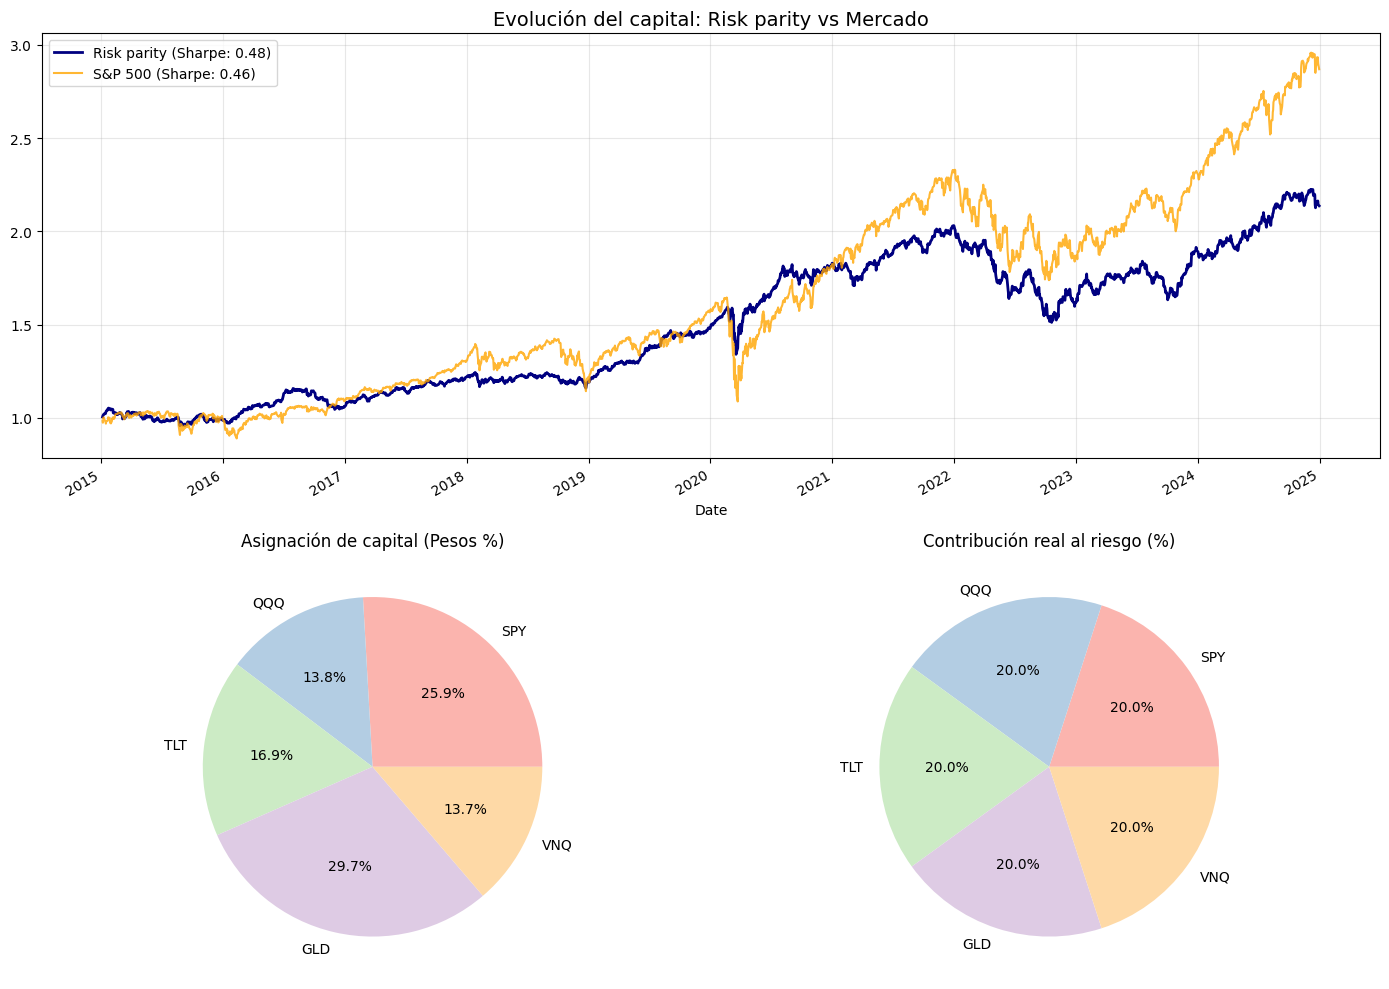


Métrica              | Risk Parity     | S&P 500
--------------------------------------------------
CAGR (Anual)         |          7.91% | 11.15%
Volatilidad          |         10.28% | 17.83%
Ratio Sharpe         |           0.48 | 0.46
Max Drawdown         |        -25.58% | -33.92%


In [2]:
#PROYECTO: Systematic_Trading_Strategies
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Construir un portafolio donde cada activo contribuya equitativamente al riesgo total

!pip install -q yfinance scipy matplotlib pandas numpy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

#1. DESCARGA DE DATOS (Multi-Asset Class)
#SPY (Acciones), QQQ (Tech), TLT (Bonos largos), GLD (Oro), VNQ (Inmobiliario)
tickers = ["SPY", "QQQ", "TLT", "GLD", "VNQ"]
start = "2015-01-01"
end = "2024-12-31"

prices = yf.download(tickers, start=start, end=end)["Close"].dropna()
returns = prices.pct_change().dropna()

#Matriz de covarianza anualizada
cov_matrix = returns.cov() * 252

#2. MOTOR MATEMÁTICO DE PARIDAD DE RIESGO (RISK PARITY)
def calculate_risk_contribution(weights, cov_matrix):
    """Calcula la contribución marginal al riesgo de cada activo."""
    portfolio_var = weights.T @ cov_matrix @ weights
    marginal_risk = cov_matrix @ weights
    risk_contribution = (weights * marginal_risk) / portfolio_var
    return risk_contribution

def risk_parity_objective(weights, cov_matrix):
    """Función objetivo: Minimizar la diferencia entre la contribución de riesgo y el objetivo (1/N)."""
    n = len(weights)
    risk_contributions = calculate_risk_contribution(weights, cov_matrix)
    target_risk = np.ones(n) / n #Objetivo: Todos aportan el mismo riesgo (20%)

    #Minimizamos el error cuadrático medio
    return np.sum((risk_contributions - target_risk)**2)

# 3. OPTIMIZACIÓN (Solver SLSQP)
n = len(tickers)
init_weights = np.ones(n) / n #Empezamos con pesos iguales (1/N)
bounds = tuple((0, 1) for _ in range(n)) #Pesos entre 0 y 100% (Long-only)
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}) #Suma de pesos = 100%

#Resolver optimización
print("Optimizando paridad de riesgo...")
result = minimize(
    risk_parity_objective,
    init_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

rp_weights = result.x
rp_risk_contributions = calculate_risk_contribution(rp_weights, cov_matrix)

#4. BACKTESTING Y MÉTRICAS DE PERFORMANCE
portfolio_returns = returns @ rp_weights

#Benchmark (S&P 500)
sp500 = yf.download("^GSPC", start=start, end=end)["Close"].dropna()
sp_returns = sp500.pct_change()["^GSPC"].loc[portfolio_returns.index]

def get_metrics(ret_series):
    cum_ret = (1 + ret_series).cumprod()
    cagr = (1 + cum_ret.iloc[-1] - 1)**(1 / (len(ret_series)/252)) - 1
    vol = ret_series.std() * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol
    max_dd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()
    return cagr, vol, sharpe, max_dd

rp_m = get_metrics(portfolio_returns)
sp_m = get_metrics(sp_returns)

#5. VISUALIZACIÓN INSTITUCIONAL

fig = plt.figure(figsize=(14, 10))

#Gráfico 1: Equity curve
ax1 = plt.subplot(2, 1, 1)
((1 + portfolio_returns).cumprod()).plot(ax=ax1, label=f"Risk parity (Sharpe: {rp_m[2]:.2f})", color='navy', lw=2)
((1 + sp_returns).cumprod()).plot(ax=ax1, label=f"S&P 500 (Sharpe: {sp_m[2]:.2f})", color='orange', alpha=0.8)
ax1.set_title("Evolución del capital: Risk parity vs Mercado", fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

#Gráfico 2 y 3: Pesos de capital vs contribución de Riesgo
ax2 = plt.subplot(2, 2, 3)
ax2.pie(rp_weights, labels=tickers, autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
ax2.set_title('Asignación de capital (Pesos %)')

ax3 = plt.subplot(2, 2, 4)
ax3.pie(rp_risk_contributions, labels=tickers, autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
ax3.set_title('Contribución real al riesgo (%)')

plt.tight_layout()
plt.show()

#Reporte
print(f"\n{'Métrica':<20} | {'Risk Parity':<15} | {'S&P 500'}")
print("-" * 50)
print(f"{'CAGR (Anual)':<20} | {rp_m[0]:>14.2%} | {sp_m[0]:.2%}")
print(f"{'Volatilidad':<20} | {rp_m[1]:>14.2%} | {sp_m[1]:.2%}")
print(f"{'Ratio Sharpe':<20} | {rp_m[2]:>14.2f} | {sp_m[2]:.2f}")
print(f"{'Max Drawdown':<20} | {rp_m[3]:>14.2%} | {sp_m[3]:.2%}")